In [1]:
from utils import * # includes some global functions/variables

# Global Variables

### Specify the global variables in utils.py

- A() - observation operator 
- T - final diffusion time
- alpha - noise added at 1st diffusion step
- diff_steps - number of diffusion steps
- ts - array of indecies used for indexing the diffusion process
- sigmas2_total - total noise added at each index
- del_sigmas2 - variance of noise increment added at each diffusion step
- del_sigmas - std of noise added at each diffusion step
- sigma_y - observation noise
- dims - dimentionality of the data



In [2]:
n = 1000
dims = 1

xt = torch.zeros(diff_steps, n, dims)
xt_bwd = torch.zeros_like(xt)
xt[0] = sample_p0(n).reshape((n, dims))
for t in range(1, diff_steps): # noising process
    xt[t] = xt[t-1] + del_sigmas[t-1]*torch.randn(n, dims)

#reverse the process
xt_bwd[-1] = xt[-1].clone().detach()
for t in range(diff_steps-1, 0, -1):
    score = score_pt(xt_bwd[t].clone().detach().requires_grad_(True), ts[t])
    xt_bwd[t-1] = xt_bwd[t] + del_sigmas2[t-1] * score + del_sigmas[t-1] *torch.randn(n, dims)

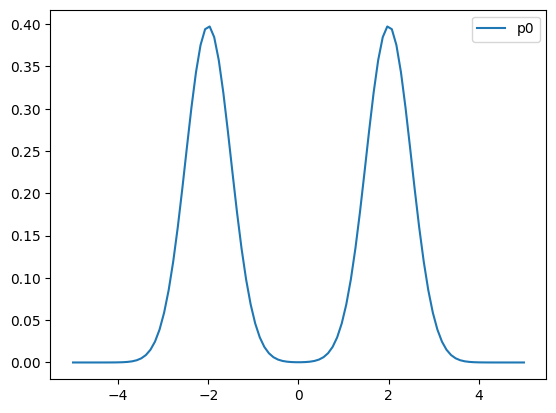

In [3]:
# plot histogram

# _ = plt.hist(xt[-1].detach().numpy(), bins=100, alpha=0.5, label='T', density=True)
# _ = plt.hist(xt_bwd[0].detach().numpy(), bins=100, alpha=0.5, label='bwd', density=True)
# _ = plt.hist(y)
x = torch.linspace(-5, 5, 100).reshape(-1, 1)
plt.plot(x.detach().numpy(), pt(x, 1).detach().numpy(), label='p0')
plt.legend()

# MC Guidance Estimates

In [ ]:
placeholder_x0 = 0.0
y =  torch.ones_like(xt[0]) * A(tensor([placeholder_x0])) # A(xt[0]) + sigma_y*torch.randn_like(xt[0]) #
print(sigma_y, A(tensor([placeholder_x0])), (1-A(tensor([placeholder_x0]))**2)**-1)

tensor([[0.0100]]) tensor([0.]) tensor([1.])


In [5]:
# Will likely fail if observation noise is too low

guidances = torch.zeros_like(xt) # loging
scores = torch.zeros_like(xt) # loging
xt_bwd = torch.zeros_like(xt) # loging
xt_bwd[-1] = xt[-1].clone().detach().requires_grad_(True) #xt[time, samples, dims]
for t in tqdm(range(diff_steps-1, 0, -1)):
    sc = score_pt(xt_bwd[t].clone().detach().requires_grad_(True), ts[t])
    guidance = get_guidance(xt_bwd[t], y, t, 1000)[0]
    guidances[t] = guidance
    scores[t] = sc
    xt_bwd[t-1] = xt_bwd[t] + del_sigmas2 [t] * (sc + guidance) + torch.randn_like(xt_bwd[t]) * del_sigmas[t-1]

100%|██████████| 49/49 [00:02<00:00, 17.71it/s]


tensor(11.0718, grad_fn=<MeanBackward0>) tensor(111.3155, grad_fn=<StdBackward0>)


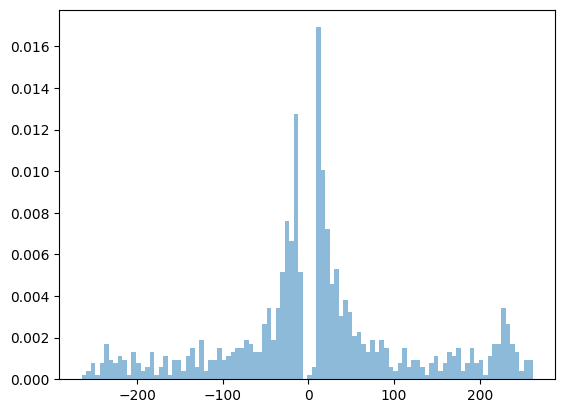

In [6]:
_ = plt.hist((xt_bwd[0]).detach().numpy(), bins=100, alpha=0.5, label='bwd', density=True)
print(xt_bwd[0].mean(), xt_bwd[0].std())

# Importance sampling Guidance Estimate



In [ ]:
placeholder_x0 = tensor([4.0]).requires_grad_(True)
y =  torch.ones_like(xt[0]) * A(placeholder_x0) # A(xt[0]) + sigma_y*torch.randn_like(xt[0]) #
y_temp = A(placeholder_x0).requires_grad_(True)
partial_A = torch.autograd.grad(y_temp, placeholder_x0, torch.ones_like(placeholder_x0), create_graph=True)[0]
print(sigma_y, y[0].item(), A(placeholder_x0).item(), partial_A**-1)

guidances = torch.zeros_like(xt) # logging
scores = torch.zeros_like(xt) # logging
xt_bwd = torch.zeros_like(xt) # logging
xt_bwd[-1] = xt[-1].clone().detach().requires_grad_(True) #xt[time, samples, dims]
for t in tqdm(range(diff_steps-1, 0, -1)):
    sc = score_pt(xt_bwd[t].clone().detach().requires_grad_(True), ts[t])
    guidance = get_guidance_IS(y, xt_bwd[t].detach().requires_grad_(True), t, 1000)[0]
    guidances[t] = guidance
    scores[t] = sc
    xt_bwd[t-1] = xt_bwd[t] + del_sigmas2 [t] * (sc + guidance) + torch.randn_like(xt_bwd[t]) * del_sigmas[t-1]

tensor([[0.0100]]) 1.9280551671981812 1.9280551671981812 tensor([14.1541], grad_fn=<PowBackward0>)


100%|██████████| 49/49 [00:21<00:00,  2.24it/s]


Text(0.5, 0, 'x (denoised)')

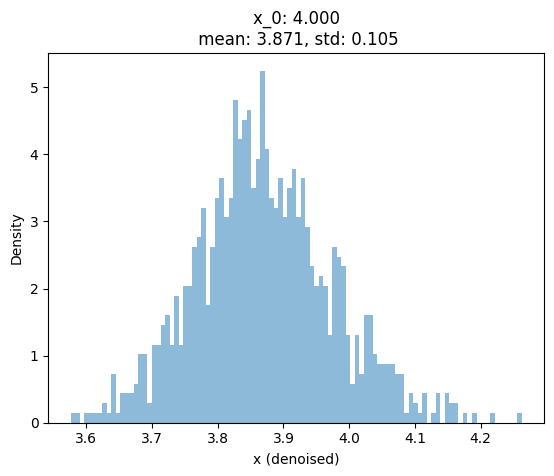

In [ ]:
_ = plt.hist((xt_bwd[0]).detach().numpy(), bins=100, alpha=0.5, label='bwd', density=True)
# _ = plt.hist(y.detach().numpy(), bins=100, alpha=0.5, label='y', density=True)
mean = xt_bwd[0].mean()
std = xt_bwd[0].std()

plt.title(f'x_0: {placeholder_x0.item():.3f}\n mean: {mean.item():.3f}, std: {std.item():.3f}')
plt.ylabel('Density')
plt.xlabel('x (denoised)')

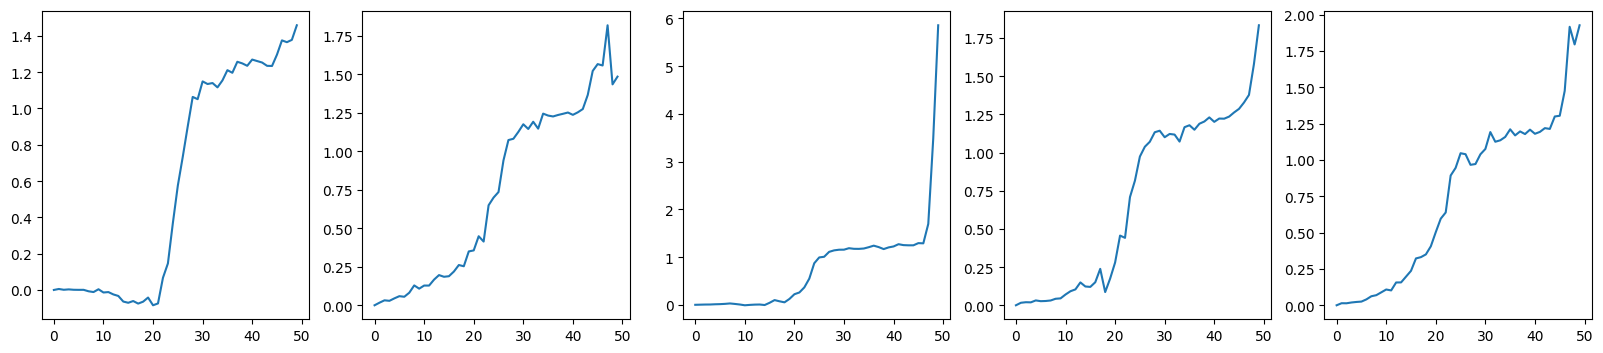

In [24]:
top_5_indices = torch.topk(guidances.abs().flatten(), 5).indices
top_5_locations = torch.unravel_index(top_5_indices, guidances.shape)
idx = top_5_locations[1]

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i, ax in zip([5,6,7,8,9], axs):
    ax.plot(sigmas2_total[1:] * guidances[:, i, 0].detach().numpy(), label=f'idx={i}')
    # ax.legend()